# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
Analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

In [1]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
C:\Users\soniv\Desktop\Bitcoin_Sentiment_Analysis\notebooks


## Data Loading

In [2]:
import pandas as pd

trades = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


## 2. Data Inspection

In [3]:
print("TRADES COLUMNS:")
print(trades.columns.tolist())

print("\n" + "="*60 + "\n")

print("SENTIMENT COLUMNS:")
print(sentiment.columns.tolist())

TRADES COLUMNS:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


SENTIMENT COLUMNS:
['timestamp', 'value', 'classification', 'date']


In [4]:
print("TRADES MISSING VALUES:")
print(trades.isnull().sum())

print("\n" + "="*60 + "\n")

print("SENTIMENT MISSING VALUES:")
print(sentiment.isnull().sum())

TRADES MISSING VALUES:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


SENTIMENT MISSING VALUES:
timestamp         0
value             0
classification    0
date              0
dtype: int64


## 4. Data Preparation

In [5]:
print("Trader Timestamp Sample:")
print(trades["Timestamp IST"].head())

print("\n" + "="*60 + "\n")

print("Sentiment Date Sample:")
print(sentiment["date"].head())

Trader Timestamp Sample:
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object


Sentiment Date Sample:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [6]:
# Convert trader timestamp
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Extract date only
trades["Date"] = trades["Timestamp IST"].dt.date

# Convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Extract date only
sentiment["Date"] = sentiment["date"].dt.date

# Verify
print(trades[["Timestamp IST", "Date"]].head())

print("\n" + "="*60 + "\n")

print(sentiment[["date", "Date"]].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


## Data Preparation and Merging

In [7]:

df = trades.merge(
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print("Merged Shape:", df.shape)

print("\nMissing Sentiment Labels:")
print(df["classification"].isnull().sum())

print("\nSample Rows:")
print(df[["Date", "Coin", "Closed PnL", "classification", "value"]].head())

Merged Shape: (211224, 19)

Missing Sentiment Labels:
6

Sample Rows:
         Date  Coin  Closed PnL classification  value
0  2024-12-02  @107         0.0  Extreme Greed   80.0
1  2024-12-02  @107         0.0  Extreme Greed   80.0
2  2024-12-02  @107         0.0  Extreme Greed   80.0
3  2024-12-02  @107         0.0  Extreme Greed   80.0
4  2024-12-02  @107         0.0  Extreme Greed   80.0


In [8]:
# Remove rows without sentiment
df = df.dropna(subset=["classification"])

print("New Shape:", df.shape)

print("\nRemaining Missing Labels:")
print(df["classification"].isnull().sum())

New Shape: (211218, 19)

Remaining Missing Labels:
0


## 6. Profitability Analysis by Market Sentiment

In [9]:
sentiment_pnl = df.groupby("classification")["Closed PnL"].agg(
    Trade_Count="count",
    Total_PnL="sum",
    Average_PnL="mean",
    Median_PnL="median"
).sort_values(by="Total_PnL", ascending=False)

print(sentiment_pnl)

                Trade_Count     Total_PnL  Average_PnL  Median_PnL
classification                                                    
Fear                  61837  3.357155e+06    54.290400         0.0
Extreme Greed         39992  2.715171e+06    67.892861         0.0
Greed                 50303  2.150129e+06    42.743559         0.0
Neutral               37686  1.292921e+06    34.307718         0.0
Extreme Fear          21400  7.391102e+05    34.537862         0.0


## 7. Win Rate Analysis

In [10]:
# Create win/loss flag
df["Win"] = df["Closed PnL"] > 0

# Win rate by sentiment
win_rate = df.groupby("classification")["Win"].agg(
    Trade_Count="count",
    Win_Rate=lambda x: round(x.mean()*100, 2)
).sort_values(by="Win_Rate", ascending=False)

print(win_rate)

                Trade_Count  Win_Rate
classification                       
Extreme Greed         39992     46.49
Fear                  61837     42.08
Neutral               37686     39.70
Greed                 50303     38.48
Extreme Fear          21400     37.06


In [11]:
direction_analysis = df.groupby(
    ["classification", "Direction"]
)["Closed PnL"].agg(
    Trade_Count="count",
    Total_PnL="sum",
    Average_PnL="mean"
)

print(direction_analysis)

                                          Trade_Count     Total_PnL  \
classification Direction                                              
Extreme Fear   Buy                                807  0.000000e+00   
               Close Long                        6241  5.067528e+05   
               Close Short                       3117  3.846385e+05   
               Long > Short                         5  6.659778e+00   
               Open Long                         7005  0.000000e+00   
               Open Short                        3174  0.000000e+00   
               Sell                              1042 -1.406926e+05   
               Short > Long                         6 -1.159510e+04   
               Spot Dust Conversion                 3  0.000000e+00   
Extreme Greed  Buy                               5132  0.000000e+00   
               Close Long                        7186  4.443160e+05   
               Close Short                       6497  1.882213e+05   
      

## 8. Long vs Short Strategy Analysis

In [12]:
closed_trades = df[
    df["Direction"].isin(["Close Long", "Close Short"])
]

closed_analysis = closed_trades.groupby(
    ["classification", "Direction"]
)["Closed PnL"].agg(
    Trade_Count="count",
    Total_PnL="sum",
    Average_PnL="mean"
)

print(closed_analysis)

                            Trade_Count     Total_PnL  Average_PnL
classification Direction                                          
Extreme Fear   Close Long          6241  5.067528e+05    81.197371
               Close Short         3117  3.846385e+05   123.400238
Extreme Greed  Close Long          7186  4.443160e+05    61.830783
               Close Short         6497  1.882213e+05    28.970490
Fear           Close Long         17260  1.432582e+06    83.000111
               Close Short         9221  1.914986e+06   207.676658
Greed          Close Long          7998  7.114905e+05    88.958554
               Close Short        11322  6.249234e+05    55.195496
Neutral        Close Long          9993  5.277882e+05    52.815787
               Close Short         5850  5.545584e+05    94.796313


## 9. Trading Activity Analysis

In [13]:
trade_activity = df.groupby("classification").size().sort_values(ascending=False)

print(trade_activity)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
dtype: int64


In [14]:
sentiment_distribution = (
    df["classification"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_distribution)

classification
Fear             29.28
Greed            23.82
Extreme Greed    18.93
Neutral          17.84
Extreme Fear     10.13
Name: proportion, dtype: float64


## 10. Visualizations

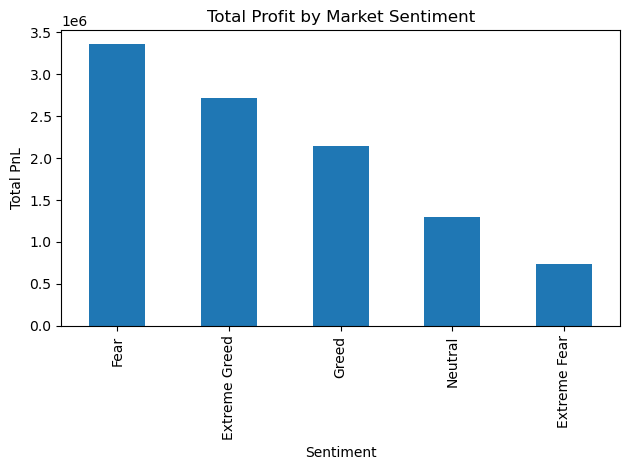

Chart saved successfully!


In [16]:
import matplotlib.pyplot as plt

sentiment_pnl["Total_PnL"].plot(kind="bar")

plt.title("Total Profit by Market Sentiment")
plt.ylabel("Total PnL")
plt.xlabel("Sentiment")

plt.tight_layout()

plt.savefig("../charts/total_profit_by_sentiment.png", dpi=300)

plt.show()

print("Chart saved successfully!")

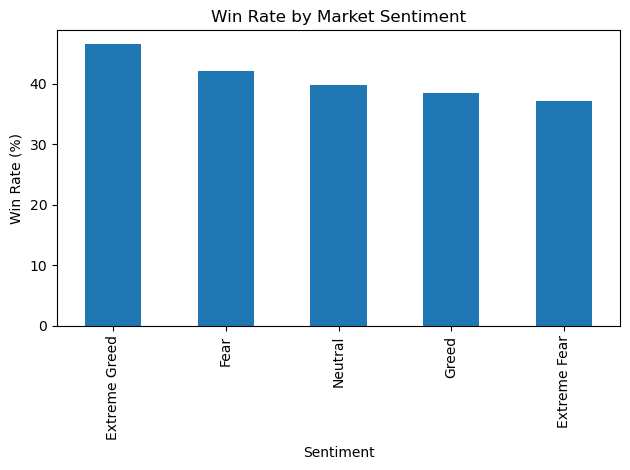

Chart saved successfully!


In [17]:
import matplotlib.pyplot as plt

win_rate["Win_Rate"].plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xlabel("Sentiment")

plt.tight_layout()

plt.savefig("../charts/win_rate_by_sentiment.png", dpi=300)

plt.show()

print("Chart saved successfully!")

In [18]:
strategy_data = closed_trades.groupby(
    ["classification", "Direction"]
)["Closed PnL"].mean().unstack()

print(strategy_data)

Direction       Close Long  Close Short
classification                         
Extreme Fear     81.197371   123.400238
Extreme Greed    61.830783    28.970490
Fear             83.000111   207.676658
Greed            88.958554    55.195496
Neutral          52.815787    94.796313


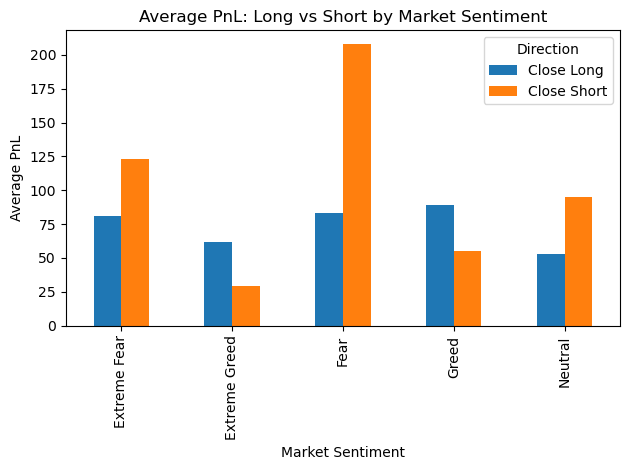

Chart saved successfully!


In [19]:
import matplotlib.pyplot as plt

strategy_data.plot(kind="bar")

plt.title("Average PnL: Long vs Short by Market Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")

plt.tight_layout()

plt.savefig("../charts/long_vs_short_by_sentiment.png", dpi=300)

plt.show()

print("Chart saved successfully!")

In [20]:
summary_table = pd.DataFrame({
    "Total_PnL": sentiment_pnl["Total_PnL"],
    "Average_PnL": sentiment_pnl["Average_PnL"],
    "Win_Rate(%)": win_rate["Win_Rate"]
})

summary_table = summary_table.round(2)

print(summary_table)

                 Total_PnL  Average_PnL  Win_Rate(%)
classification                                      
Extreme Fear     739110.25        34.54        37.06
Extreme Greed   2715171.31        67.89        46.49
Fear            3357155.44        54.29        42.08
Greed           2150129.27        42.74        38.48
Neutral         1292920.68        34.31        39.70


In [21]:
summary_table.to_csv(
    "../outputs/sentiment_summary.csv"
)

print("Summary table saved!")

Summary table saved!


## 11. Key Findings

- Fear generated the highest total profit (3.36M).
- Extreme Greed generated the highest average profit per trade (67.89).
- Extreme Greed achieved the highest win rate (46.49%).
- Long positions outperformed during Greed and Extreme Greed.
- Short positions outperformed during Fear and Extreme Fear.
- Fear accounted for 29.28% of all trading activity.

## Conclusion

Market sentiment significantly influences trader performance. Long-biased strategies perform better during Greed conditions, while Short-biased strategies perform better during Fear conditions.